# Customer Churn — Feature Engineering
**Input:**  (7032 rows, 20 features)  
**Goal:** Build new features that help the model predict churn better  
**New features:** tenure_group · num_services · is_new_customer · CLV · avg_service_cost · high_risk_flag

In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

# Load clean data from Phase 1
df = pd.read_csv("../data/processed/telco_churn_clean.csv")
print("Shape:", df.shape)
df.head()

Shape: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,1,0,1,0,0,1,0,1,0,0,0,0,0,1,0,29.85,29.85,0
1,0,0,0,0,34,1,0,1,1,0,1,0,0,0,1,0,1,56.95,1889.50,0
2,0,0,0,0,2,1,0,1,1,1,0,0,0,0,0,1,1,53.85,108.15,1
3,0,0,0,0,45,0,0,1,1,0,1,1,0,0,1,0,2,42.30,1840.75,0
4,1,0,0,0,2,1,0,2,0,0,0,0,0,0,0,1,0,70.70,151.65,1


## 1. Tenure Group
Raw tenure (1–72 months) converted into 4 meaningful business segments.
A customer with tenure=2 and tenure=11 are both "new" — grouping captures the business meaning better than raw numbers.

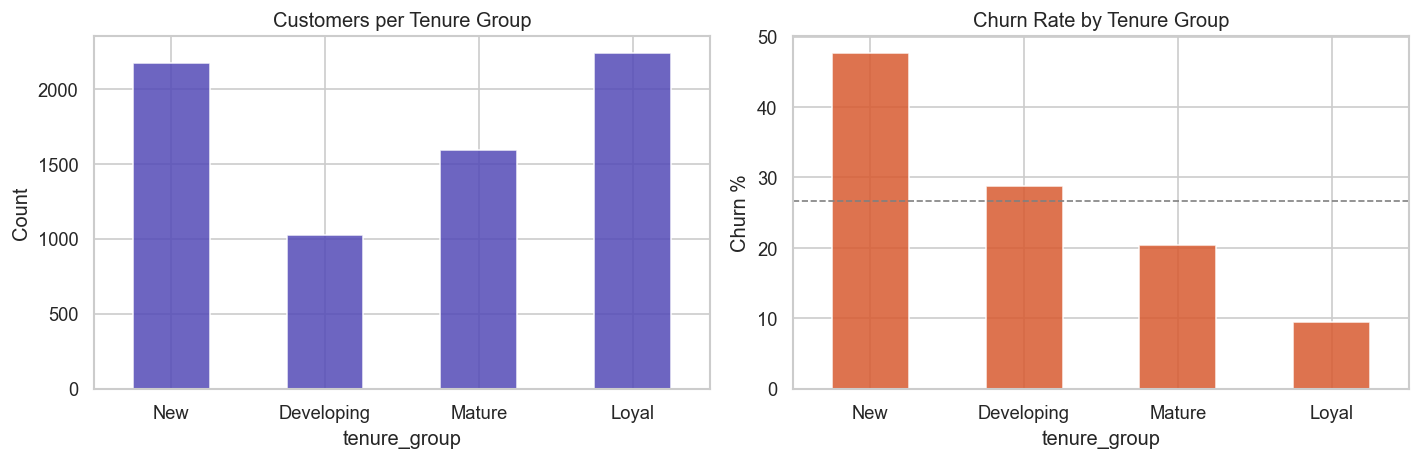

tenure_group
New           47.7
Developing    28.7
Mature        20.4
Loyal          9.5
Name: Churn, dtype: float64


In [13]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["New", "Developing", "Mature", "Loyal"]
)

# Churn rate per tenure group
tenure_churn = df.groupby("tenure_group")["Churn"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Distribution of customers per group
df["tenure_group"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="#534AB7", alpha=0.85
)
axes[0].set_title("Customers per Tenure Group")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

# Churn rate per group
tenure_churn.plot(kind="bar", ax=axes[1], color="#D85A30", alpha=0.85)
axes[1].set_title("Churn Rate by Tenure Group")
axes[1].set_ylabel("Churn %")
axes[1].tick_params(axis="x", rotation=0)
axes[1].axhline(26.6, color="gray", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()
print(tenure_churn.round(1))

> **Finding:** New customers (0–12 months) churn at ~47.7% — nearly double the overall average.  
> Loyal customers (48–72 months) churn at less than 10%.

## 2. Number of Services
Counts how many services each customer subscribes to.  
Customers using more services are more embedded and less likely to churn.

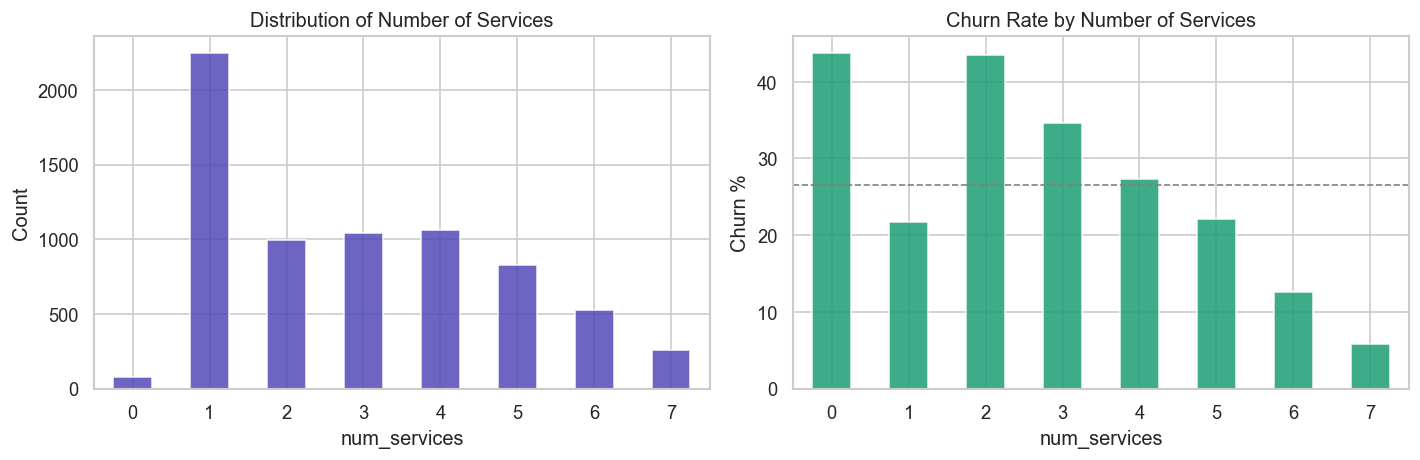

num_services
0    43.8
1    21.7
2    43.5
3    34.7
4    27.3
5    22.1
6    12.6
7     5.8
Name: Churn, dtype: float64


In [14]:
services = [
    "PhoneService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"
]

df["num_services"] = df[services].sum(axis=1)

# Churn rate by number of services
services_churn = df.groupby("num_services")["Churn"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4)) 

df["num_services"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="#534AB7", alpha=0.85
)

axes[0].set_title("Distribution of Number of Services")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

services_churn.plot(kind="bar", ax=axes[1], color="#1D9E75", alpha=0.85)
axes[1].set_title("Churn Rate by Number of Services")
axes[1].set_ylabel("Churn %")
axes[1].tick_params(axis="x", rotation=0)
axes[1].axhline(26.6, color="gray", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()
print(services_churn.round(1))

> **Finding:** Customers with 0–2 services churn most. Customers with 5+ services churn significantly less — they are deeply embedded in the ecosystem.

## 3. New Customer Flag
Binary flag — 1 if tenure ≤ 12 months, 0 otherwise.  
Directly captures the highest risk group identified in EDA.

Customer counts:
  Existing (0): 4857
  New      (1): 2175
Churn rate:
  Existing customers: 17.1%
  New customers:      47.7%


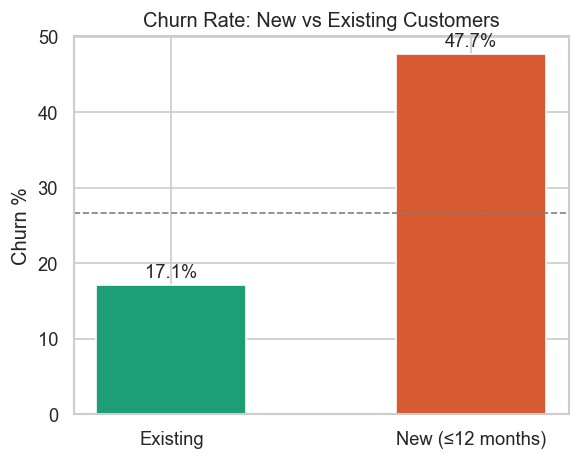

In [15]:
df["is_new_customer"] = (df["tenure"] <= 12).astype(int)

new_churn = df.groupby("is_new_customer")["Churn"].mean() * 100
counts = df["is_new_customer"].value_counts()

print("Customer counts:")
print(f"  Existing (0): {counts[0]}")
print(f"  New      (1): {counts[1]}")

print("Churn rate:")
print(f"  Existing customers: {new_churn[0]:.1f}%")
print(f"  New customers:      {new_churn[1]:.1f}%")

fig, ax = plt.subplots(figsize=(5,4))
ax.bar(["Existing", "New (≤12 months)"],
        new_churn.values,
        color=["#1D9E75","#D85A30"], width=0.5)
ax.axhline(26.6, color="gray", linestyle="--", linewidth=1)
ax.set_title("Churn Rate: New vs Existing Customers")
ax.set_ylabel("Churn %")

for i, v in enumerate(new_churn.values):
    ax.text(i, v+1, f"{v:.1f}%", ha="center", fontsize=11)

plt.tight_layout()
plt.show()

> **Finding:** New customers churn at ~47.7% vs ~17.1% for existing customers — confirming early tenure is the danger zone.

## 4. Customer Lifetime Value (CLV)
Total revenue generated by a customer since joining.  
  
Helps prioritise which at-risk customers are most valuable to retain.

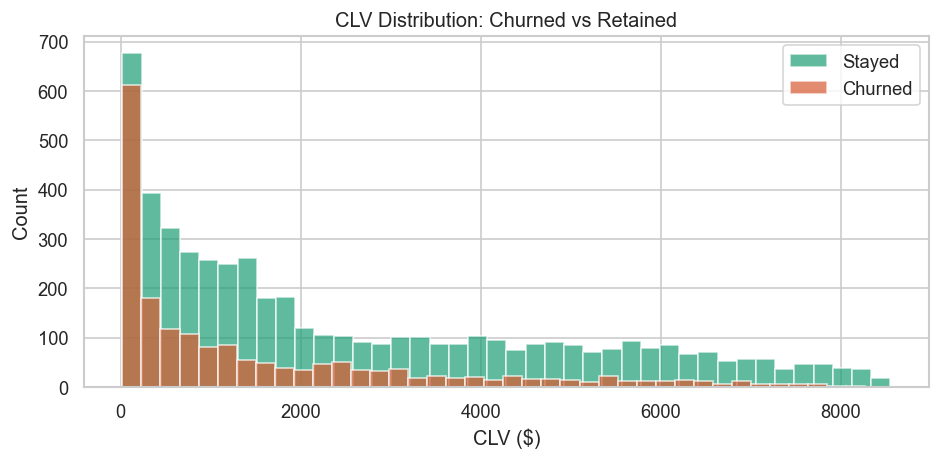

Avg CLV - Stayed :  2555.2
Avg CLV - Churned:  1531.61


In [16]:
df["CLV"] = df["tenure"] * df["MonthlyCharges"]

# CLV distribution by churn
fig, ax = plt.subplots(figsize=(8, 4))
df[df["Churn"] == 0]["CLV"].hist(
    bins=40, ax=ax, alpha=0.7, color="#1D9E75", label="Stayed"
)
df[df["Churn"] == 1]["CLV"].hist(
    bins=40, ax=ax, alpha=0.7, color="#D85A30", label="Churned"
)

ax.set_title("CLV Distribution: Churned vs Retained")
ax.set_xlabel("CLV ($)")
ax.set_ylabel("Count")
ax.legend()

plt.tight_layout()
plt.show()

print("Avg CLV - Stayed : ", df[df["Churn"]==0]["CLV"].mean().round(2))
print("Avg CLV - Churned: ", df[df["Churn"]==1]["CLV"].mean().round(2))

> **Finding:** Retained customers have significantly higher CLV than churners — confirming that retaining even a small % of churners saves significant revenue.

## 5. Average Service Cost
  
Customers paying high charges but using few services get poor value — high churn risk.

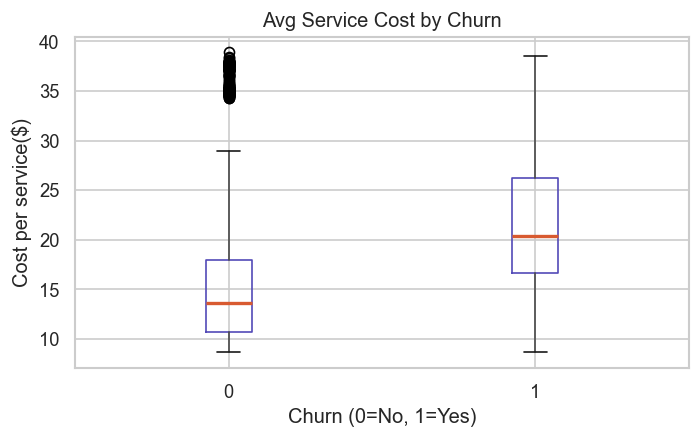

Avg cost/service - Stayed:  15.43
Avg cost/service - Churned: 21.69


In [17]:
df["avg_service_cost"] = df["MonthlyCharges"] / (df["num_services"] + 1)

# Compare avg_service_cost between churned and retained
fig, ax = plt.subplots(figsize=(6, 4))

df.boxplot(
    column="avg_service_cost", by="Churn", ax=ax,
    boxprops=dict(color="#534AB7"),
    medianprops=dict(color="#D85A30", linewidth=2)
)

ax.set_title("Avg Service Cost by Churn")
ax.set_xlabel("Churn (0=No, 1=Yes)")
ax.set_ylabel("Cost per service($)")

plt.suptitle("")
plt.tight_layout()
plt.show()

print("Avg cost/service - Stayed: ", df[df["Churn"]==0]["avg_service_cost"].mean().round(2))
print("Avg cost/service - Churned:", df[df["Churn"]==1]["avg_service_cost"].mean().round(2))

> **Finding:** Churners pay **40% more per service** ($21.69) vs retained customers ($15.43) — 
> they subscribe to fewer services but pay similar monthly charges, giving them poor value for money.
> The wider box for churners (right) shows more variability — some churners pay up to $38 per service.

## 6. High Risk Flag
Combines two strongest churn signals from EDA into one binary flag:  
- Month-to-month contract AND
- New customer (tenure ≤ 12 months)  

This directly targets the highest churn segment.

High risk customers: 1994
Normal customers   : 5038
Churn rate:
  Normal   : 16.8%
  High risk: 51.4%


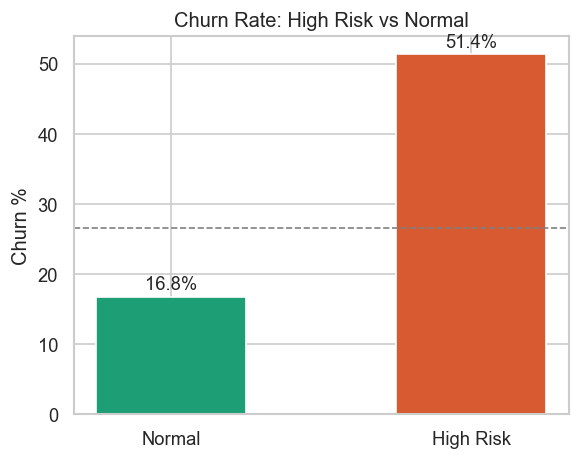

In [18]:
df["high_risk_flag"] = (
    (df["Contract"] == 0) & (df["is_new_customer"] == 1)
).astype(int)

high_risk_churn = df.groupby("high_risk_flag")["Churn"].mean() * 100
counts = df["high_risk_flag"].value_counts()

print("High risk customers:", counts.get(1, 0))
print("Normal customers   :", counts.get(0, 0))
print("Churn rate:")
print(f"  Normal   : {high_risk_churn[0]:.1f}%")
print(f"  High risk: {high_risk_churn[1]:.1f}%")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Normal", "High Risk"],
       high_risk_churn.values,
       color=["#1D9E75", "#D85A30"], width=0.5)
ax.axhline(26.6, color="gray", linestyle="--", linewidth=1)
ax.set_title("Churn Rate: High Risk vs Normal")
ax.set_ylabel("Churn %")

for i, v in enumerate(high_risk_churn.values):
    ax.text(i, v+1, f"{v:.1f}%", ha="center", fontsize=11)

plt.tight_layout()
plt.show()

> **Finding:** High risk customers (month-to-month + new) churn at **51.4%** — 
> 3× higher than normal customers (16.8%).  
> 1,994 out of 7,032 customers fall in this high risk group — **28.4% of your entire customer base.**  
> These are the customers to target first with retention offers.

## 7. Feature Summary
Overview of all new features added and their correlation with Churn.

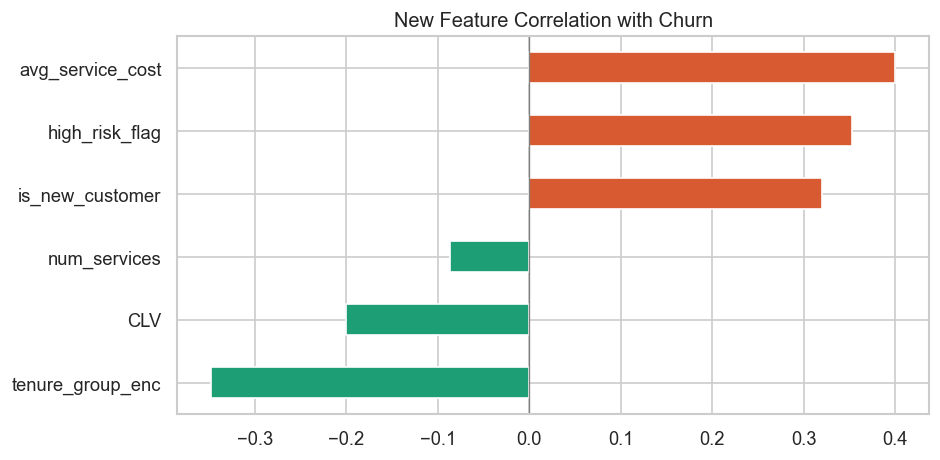

tenure_group_enc   -0.347
CLV                -0.200
num_services       -0.086
is_new_customer     0.320
high_risk_flag      0.353
avg_service_cost    0.399
Name: Churn, dtype: float64


In [19]:
# Encode tenure_group for correlation
df["tenure_group_enc"] = df["tenure_group"].map(
    {"New": 0, "Developing": 1, "Mature": 2, "Loyal": 3}
)

new_features = ["tenure_group_enc", "num_services", "is_new_customer",
                "CLV", "avg_service_cost", "high_risk_flag"]

corr_new = df[new_features + ["Churn"]].corr()["Churn"].drop("Churn").sort_values()

colors = ["#D85A30" if v > 0 else "#1D9E75" for v in corr_new.values]

fig, ax = plt.subplots(figsize=(8, 4))
corr_new.plot(kind="barh", ax=ax, color=colors)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_title("New Feature Correlation with Churn")

plt.tight_layout()
plt.show()
print(corr_new.round(3))

## 8. Save Engineered Dataset

In [20]:
# Drop encoded tenure_group used only for correlation chart
df.drop(columns=["tenure_group_enc"], inplace=True)

df.to_csv("../data/processed/telco_churn_features.csv", index=False)

print("Saved Final shape:", df.shape)
print("New columns added:")

print([c for c in df.columns if c not in [
    "gender", "SeniorCitizen", "Partner", "Dependents", "tenure",
    "PhoneService", "MultipleLines", "InternetService", "OnlineSecurity",
    "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV",
    "StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod",
    "MonthlyCharges", "TotalCharges", "Churn"
]])

Saved Final shape: (7032, 26)
New columns added:
['tenure_group', 'num_services', 'is_new_customer', 'CLV', 'avg_service_cost', 'high_risk_flag']


## Key Findings

| Feature | What it captures | Churn signal |
|---------|-----------------|-------------|
| `tenure_group` | Business lifecycle stage | New = 47.7% churn, Loyal = <10% churn |
| `num_services` | Customer engagement depth | 0 services = 43.8% churn, 7 services = 5.8% churn |
| `is_new_customer` | Binary danger zone flag | New = 47.7% vs existing = 17.1% churn |
| `CLV` | Total revenue generated | Churners 66% lower CLV ($1,531 vs $2,555) |
| `avg_service_cost` | Value-for-money signal | Churners pay 40% more per service ($21.69 vs $15.43) |
| `high_risk_flag` | Combined highest risk | 51.4% churn — affects 28.4% of all customers (1,994) |

**Next → `03_model.ipynb`** — Model Training with LightGBM + SHAP